# **<center>1. Imports</center>**

In [1]:
# Standard library
import os
import re
import random
import shutil
import math

from pathlib import Path
from collections import Counter, defaultdict

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Dataset inspection
import torch
from torch.utils.data import ConcatDataset
from torchvision import datasets

# Local configuration
from dotenv import load_dotenv

In [2]:
from dotenv import load_dotenv

CONFIG_FILE = Path.home() / ".wadidegla.env"

if not CONFIG_FILE.exists():
    raise FileNotFoundError(
        "Local WadiDegla configuration file was not found."
    )

load_dotenv(CONFIG_FILE)

DATA_DIR = Path(os.environ["WADIDEGLA_DATA_DIR"])

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "The configured WadiDegla dataset directory does not exist."
    )

print("WadiDegla dataset configuration loaded successfully.")

WadiDegla dataset configuration loaded successfully.


# <center>**3. Data Splitting**</center>
- **Document the hybrid Train/Validation splitting strategy used for the Wadi Degla dataset: 22 target species were manually separated by collection date, one target species was manually separated by sampling site, nine target species were split using code-based image-level random sampling because of limited temporal coverage, and the 500-image `others` class was divided programmatically into 400 training and 100 validation images.**

## Single-Date Random Split

In [45]:
def split_images(src_dir, dest_dir, num_images, move=False, seed=42):
    """
    Move or copy a specific number of images from src_dir to dest_dir, 
    ignoring hidden files (e.g., .DS_Store).
    """
    # Make sure destination directory exists
    os.makedirs(dest_dir, exist_ok=True)
    src_dir = Path(src_dir)
    dest_dir = Path(dest_dir)

    # List all visible files in source (ignore hidden ones)
    all_files = [
        f for f in os.listdir(src_dir) 
        if os.path.isfile(os.path.join(src_dir, f)) and not f.startswith('.')
    ]

    if len(all_files) == 0:
        raise ValueError(f"No valid (non-hidden) files found in {src_dir}")

    if num_images > len(all_files):
        raise ValueError(f"Requested {num_images} images, but only {len(all_files)} available in {src_dir}")

    # Reproducible random sample
    random.seed(seed)
    selected_files = random.sample(all_files, num_images)

    # Copy or move
    for file_name in selected_files:
        src_path = os.path.join(src_dir, file_name)
        dest_path = os.path.join(dest_dir, file_name)
        if move:
            shutil.move(src_path, dest_path)
        else:
            shutil.copy2(src_path, dest_path)

    src_relative = src_dir.relative_to(DATA_DIR)
    dest_relative = dest_dir.relative_to(DATA_DIR)
    
    print(
        f"{'Moved' if move else 'Copied'} {len(selected_files)} images "
        f"from {src_relative} → {dest_relative}"
    )

In [46]:
def count_images_split(train_dir, val_dir):
    """
    Count all image files in train and validation directories (recursively)
    and print totals with percentage split.
    """
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
    
    def count_images(directory):
        directory = Path(directory)
        return sum(
            1
            for f in directory.rglob('*')
            if f.is_file()
            and not f.name.startswith('.')
            and f.suffix.lower() in image_extensions
        )

    train_count = count_images(train_dir)
    val_count = count_images(val_dir)
    total = train_count + val_count

    train_pct = (train_count / total * 100) if total > 0 else 0
    val_pct = (val_count / total * 100) if total > 0 else 0

    print(f"Train images: {train_count} ({train_pct:.2f}%)")
    print(f"Validation images: {val_count} ({val_pct:.2f}%)")
    print(f"Total images: {total}")

    return train_count, val_count, total

In [8]:
# Move 22 randomly selected Peganum harmala images from the single available collection date to the validation set.
split_images(
    src_dir = DATA_DIR / 'Train/Peganum harmala L./04-01-2025 (85)',
    dest_dir= DATA_DIR / 'Validation/Peganum harmala L./04-01-2025 (22) Validation',
    num_images=22,
    move=True   # set True if you want to move instead of copy
)

Moved 22 images from Train/Peganum harmala L./04-01-2025 (85) → Validation/Peganum harmala L./04-01-2025 (22) Validation


In [11]:
# Move 85 random images from class1/date1 to validation folder
split_images(
    src_dir = DATA_DIR / 'Train/Rumex vesicarius L./31-01-2025 (340)',
    dest_dir = DATA_DIR / 'Validation/Rumex vesicarius L./31-01-2025 (85) Validation',
    num_images=85,
    move=True   # set True if you want to move instead of copy
)

Moved 85 images from Train/Rumex vesicarius L./31-01-2025 (340) → Validation/Rumex vesicarius L./31-01-2025 (85) Validation


## **Random Split for the "others" Class**

In [47]:
# Move 100 random images from class1/date1 to validation folder
split_images(
    src_dir = DATA_DIR / 'Train/others/PlantNet (400)',
    dest_dir = DATA_DIR / 'Validation/others/PlantNet (100) Validation',
    num_images=100,
    move=True   # set True if you want to move instead of copy
)

Moved 100 images from Train/others/PlantNet (400) → Validation/others/PlantNet (100) Validation


## **Random Split for Plant Species with Limited Collection Dates**

### **Deverra tortuosa (Desf.) DC.**

In [3]:
class_name = "Deverra tortuosa (Desf.) DC."

In [10]:
for src_dir in (DATA_DIR/f'Train/{class_name}').iterdir():
    if not src_dir.name.startswith('.'):
        dest_dir = Path(str(src_dir).replace("/Train/", "/Validation/"))
        num_images = sum(1 for f in src_dir.iterdir() if f.is_file() and not f.name.startswith('.'))
        split_images(
    src_dir = src_dir,
    dest_dir = dest_dir.with_name(dest_dir.name + " Validation"),
    num_images=math.ceil(num_images*0.2),
    move=True   # set True if you want to move instead of copy
                    )

Moved 7 images from Train/Deverra tortuosa (Desf.) DC./21-02-2025 k3 → Validation/Deverra tortuosa (Desf.) DC./21-02-2025 k3 Validation
Moved 7 images from Train/Deverra tortuosa (Desf.) DC./21-02-2025 → Validation/Deverra tortuosa (Desf.) DC./21-02-2025 Validation
Moved 25 images from Train/Deverra tortuosa (Desf.) DC./23-12-2024 → Validation/Deverra tortuosa (Desf.) DC./23-12-2024 Validation


In [11]:
train_count, val_count, total = count_images_split(DATA_DIR / f"Train/{class_name}", DATA_DIR / f"Validation/{class_name}")

Train images: 156 (80.00%)
Validation images: 39 (20.00%)
Total images: 195


### **Stachys aegyptiaca Pers.**

In [16]:
class_name = "Stachys aegyptiaca Pers."

In [17]:
for src_dir in (DATA_DIR/f'Train/{class_name}').iterdir():
    if not src_dir.name.startswith('.'):
        dest_dir = Path(str(src_dir).replace("/Train/", "/Validation/"))
        num_images = sum(1 for f in src_dir.iterdir() if f.is_file() and not f.name.startswith('.'))
        split_images(
    src_dir = src_dir,
    dest_dir = dest_dir.with_name(dest_dir.name + " Validation"),
    num_images=math.ceil(num_images*0.2),
    move=True   # set True if you want to move instead of copy
                    )

Moved 31 images from Train/Stachys aegyptiaca Pers./31-01-2025 → Validation/Stachys aegyptiaca Pers./31-01-2025 Validation
Moved 27 images from Train/Stachys aegyptiaca Pers./20-01-2024 K11 → Validation/Stachys aegyptiaca Pers./20-01-2024 K11 Validation
Moved 39 images from Train/Stachys aegyptiaca Pers./04-01-2025 → Validation/Stachys aegyptiaca Pers./04-01-2025 Validation
Moved 3 images from Train/Stachys aegyptiaca Pers./22-11-2024 K11 → Validation/Stachys aegyptiaca Pers./22-11-2024 K11 Validation


In [18]:
train_count, val_count, total = count_images_split(DATA_DIR / f"Train/{class_name}", DATA_DIR / f"Validation/{class_name}")

Train images: 391 (79.63%)
Validation images: 100 (20.37%)
Total images: 491


### **Deverra triradiata Hochst. ex Boiss.**

In [13]:
class_name = "Deverra triradiata Hochst. ex Boiss."

In [14]:
for src_dir in (DATA_DIR/f'Train/{class_name}').iterdir():
    if not src_dir.name.startswith('.'):
        dest_dir = Path(str(src_dir).replace("/Train/", "/Validation/"))
        num_images = sum(1 for f in src_dir.iterdir() if f.is_file() and not f.name.startswith('.'))
        split_images(
    src_dir = src_dir,
    dest_dir = dest_dir.with_name(dest_dir.name + " Validation"),
    num_images=math.ceil(num_images*0.2),
    move=True   # set True if you want to move instead of copy
                    )

Moved 23 images from Train/Deverra triradiata Hochst. ex Boiss./08-03-2024 → Validation/Deverra triradiata Hochst. ex Boiss./08-03-2024 Validation
Moved 5 images from Train/Deverra triradiata Hochst. ex Boiss./22-12-2023 → Validation/Deverra triradiata Hochst. ex Boiss./22-12-2023 Validation
Moved 10 images from Train/Deverra triradiata Hochst. ex Boiss./21-02-2025 → Validation/Deverra triradiata Hochst. ex Boiss./21-02-2025 Validation


In [15]:
train_count, val_count, total = count_images_split(DATA_DIR / f"Train/{class_name}", DATA_DIR / f"Validation/{class_name}")

Train images: 148 (79.57%)
Validation images: 38 (20.43%)
Total images: 186


### **Iphiona mucronata (Forssk.) Asch. & Schweinf.**

In [26]:
class_name = "Iphiona mucronata (Forssk.) Asch. & Schweinf."

In [27]:
for src_dir in (DATA_DIR/f'Train/{class_name}').iterdir():
    if not src_dir.name.startswith('.'):
        dest_dir = Path(str(src_dir).replace("/Train/", "/Validation/"))
        num_images = sum(1 for f in src_dir.iterdir() if f.is_file() and not f.name.startswith('.'))
        split_images(
    src_dir = src_dir,
    dest_dir = dest_dir.with_name(dest_dir.name + " Validation"),
    num_images=math.ceil(num_images*0.2),
    move=True   # set True if you want to move instead of copy
                    )

Moved 6 images from Train/Iphiona mucronata (Forssk.) Asch. & Schweinf./31-01-2025 (28) → Validation/Iphiona mucronata (Forssk.) Asch. & Schweinf./31-01-2025 (28) Validation
Moved 7 images from Train/Iphiona mucronata (Forssk.) Asch. & Schweinf./31-01-2025 (32) → Validation/Iphiona mucronata (Forssk.) Asch. & Schweinf./31-01-2025 (32) Validation
Moved 16 images from Train/Iphiona mucronata (Forssk.) Asch. & Schweinf./23-12-2024 → Validation/Iphiona mucronata (Forssk.) Asch. & Schweinf./23-12-2024 Validation


In [28]:
train_count, val_count, total = count_images_split(DATA_DIR / f"Train/{class_name}", DATA_DIR / f"Validation/{class_name}")

Train images: 110 (79.14%)
Validation images: 29 (20.86%)
Total images: 139


### **Anabasis articulata (Forssk.) Moq.**

In [30]:
class_name = "Anabasis articulata (Forssk.) Moq."

In [31]:
for src_dir in (DATA_DIR/f'Train/{class_name}').iterdir():
    if not src_dir.name.startswith('.'):
        dest_dir = Path(str(src_dir).replace("/Train/", "/Validation/"))
        num_images = sum(1 for f in src_dir.iterdir() if f.is_file() and not f.name.startswith('.'))
        split_images(
    src_dir = src_dir,
    dest_dir = dest_dir.with_name(dest_dir.name + " Validation"),
    num_images=math.ceil(num_images*0.2),
    move=True   # set True if you want to move instead of copy
                    )

Moved 42 images from Train/Anabasis articulata (Forssk.) Moq./31-01-2025 → Validation/Anabasis articulata (Forssk.) Moq./31-01-2025 Validation
Moved 6 images from Train/Anabasis articulata (Forssk.) Moq./22-11-2024 → Validation/Anabasis articulata (Forssk.) Moq./22-11-2024 Validation
Moved 25 images from Train/Anabasis articulata (Forssk.) Moq./04-01-2025 K7 → Validation/Anabasis articulata (Forssk.) Moq./04-01-2025 K7 Validation
Moved 3 images from Train/Anabasis articulata (Forssk.) Moq./23-12-2024 → Validation/Anabasis articulata (Forssk.) Moq./23-12-2024 Validation


In [32]:
train_count, val_count, total = count_images_split(DATA_DIR / f"Train/{class_name}", DATA_DIR / f"Validation/{class_name}")

Train images: 299 (79.73%)
Validation images: 76 (20.27%)
Total images: 375


### **Suaeda aegyptiaca (Hasselq.) Zohary**

In [33]:
class_name = "Suaeda aegyptiaca (Hasselq.) Zohary"

In [34]:
for src_dir in (DATA_DIR/f'Train/{class_name}').iterdir():
    if not src_dir.name.startswith('.'):
        dest_dir = Path(str(src_dir).replace("/Train/", "/Validation/"))
        num_images = sum(1 for f in src_dir.iterdir() if f.is_file() and not f.name.startswith('.'))
        split_images(
    src_dir = src_dir,
    dest_dir = dest_dir.with_name(dest_dir.name + " Validation"),
    num_images=math.ceil(num_images*0.2),
    move=True   # set True if you want to move instead of copy
                    )

Moved 14 images from Train/Suaeda aegyptiaca (Hasselq.) Zohary/04-01-2025 K5 → Validation/Suaeda aegyptiaca (Hasselq.) Zohary/04-01-2025 K5 Validation
Moved 2 images from Train/Suaeda aegyptiaca (Hasselq.) Zohary/07-02-2025 k9 → Validation/Suaeda aegyptiaca (Hasselq.) Zohary/07-02-2025 k9 Validation
Moved 15 images from Train/Suaeda aegyptiaca (Hasselq.) Zohary/31-01-2025 → Validation/Suaeda aegyptiaca (Hasselq.) Zohary/31-01-2025 Validation
Moved 67 images from Train/Suaeda aegyptiaca (Hasselq.) Zohary/04-01-2025 K8 → Validation/Suaeda aegyptiaca (Hasselq.) Zohary/04-01-2025 K8 Validation
Moved 10 images from Train/Suaeda aegyptiaca (Hasselq.) Zohary/07-02-2025 k5 → Validation/Suaeda aegyptiaca (Hasselq.) Zohary/07-02-2025 k5 Validation
Moved 2 images from Train/Suaeda aegyptiaca (Hasselq.) Zohary/07-02-2025 → Validation/Suaeda aegyptiaca (Hasselq.) Zohary/07-02-2025 Validation


In [35]:
train_count, val_count, total = count_images_split(DATA_DIR / f"Train/{class_name}", DATA_DIR / f"Validation/{class_name}")

Train images: 426 (79.48%)
Validation images: 110 (20.52%)
Total images: 536


### **Zilla spinosa (L.) Prantl**

In [37]:
class_name = "Zilla spinosa (L.) Prantl"

In [38]:
for src_dir in (DATA_DIR/f'Train/{class_name}').iterdir():
    if not src_dir.name.startswith('.'):
        dest_dir = Path(str(src_dir).replace("/Train/", "/Validation/"))
        num_images = sum(1 for f in src_dir.iterdir() if f.is_file() and not f.name.startswith('.'))
        split_images(
    src_dir = src_dir,
    dest_dir = dest_dir.with_name(dest_dir.name + " Validation"),
    num_images=math.ceil(num_images*0.2),
    move=True   # set True if you want to move instead of copy
                    )

Moved 17 images from Train/Zilla spinosa (L.) Prantl/31-01-2025 → Validation/Zilla spinosa (L.) Prantl/31-01-2025 Validation
Moved 8 images from Train/Zilla spinosa (L.) Prantl/22-11-2024 → Validation/Zilla spinosa (L.) Prantl/22-11-2024 Validation
Moved 10 images from Train/Zilla spinosa (L.) Prantl/08-03-2024 → Validation/Zilla spinosa (L.) Prantl/08-03-2024 Validation
Moved 48 images from Train/Zilla spinosa (L.) Prantl/04-01-2025 → Validation/Zilla spinosa (L.) Prantl/04-01-2025 Validation
Moved 5 images from Train/Zilla spinosa (L.) Prantl/22-12-2023 K12 → Validation/Zilla spinosa (L.) Prantl/22-12-2023 K12 Validation
Moved 19 images from Train/Zilla spinosa (L.) Prantl/20-01-2024 K7 → Validation/Zilla spinosa (L.) Prantl/20-01-2024 K7 Validation
Moved 9 images from Train/Zilla spinosa (L.) Prantl/23-12-2024 → Validation/Zilla spinosa (L.) Prantl/23-12-2024 Validation


In [39]:
train_count, val_count, total = count_images_split(DATA_DIR / f"Train/{class_name}", DATA_DIR / f"Validation/{class_name}")

Train images: 456 (79.72%)
Validation images: 116 (20.28%)
Total images: 572


## Dataset metadata extraction

In [55]:
def parse_folder_structure(base_path):
    data = []
    
    for species_folder in os.listdir(base_path):
        species_path = os.path.join(base_path, species_folder)
        if not os.path.isdir(species_path):
            continue


        binomial_name = species_folder

        for date_folder in os.listdir(species_path):
            date_path = os.path.join(species_path, date_folder)
            if not os.path.isdir(date_path):
                continue
                
            # Parse date and location from date folder name
            date_match = re.match(r'(\d{1,2}-\d{1,2}-\d{4})', date_folder)
            location_match = re.search(r'K\d+', date_folder, flags=re.IGNORECASE)

            date = date_match.group(1) if date_match else None
            location = location_match.group(0).upper() if location_match else None

            # Count the number of visible image files in the date folder
            image_count = sum(
                1 for item in os.listdir(date_path)
                if os.path.isfile(os.path.join(date_path, item)) and not item.startswith('.')
            )

            # Append data to the list
            data.append({
                "Binomial Name": binomial_name,
                "Date": date,
                "Number of Images": image_count,
                "Location": location
            })

    # Create a DataFrame from the data
    df = pd.DataFrame(data)
    return df

# Set the base path to the root directory (where species folders are now directly stored)
train_path = DATA_DIR / "Train"
val_path = DATA_DIR / "Validation"

# Generate the DataFrame
TrainSpeciesDataset = parse_folder_structure(train_path)
ValSpeciesDataset = parse_folder_structure(val_path)

## **Check for Overlapping Dates Between Train & Validation Sets**

In [56]:
# Merge on Binomial Name + Date
overlap = pd.merge(
    TrainSpeciesDataset[['Binomial Name', 'Date']],
    ValSpeciesDataset[['Binomial Name', 'Date']],
    on=['Binomial Name', 'Date'],
    how='inner'
)


species_with_overlap = overlap['Binomial Name'].unique()
print(f"Species with overlapping dates between Train and Val: {species_with_overlap.tolist()}")
overlap

Species with overlapping dates between Train and Val: ['Deverra tortuosa (Desf.) DC.', 'Stachys aegyptiaca Pers.', 'Peganum harmala L.', 'others', 'Zilla spinosa (L.) Prantl', 'Deverra triradiata Hochst. ex Boiss.', 'Suaeda aegyptiaca (Hasselq.) Zohary', 'Iphiona mucronata (Forssk.) Asch. & Schweinf.', 'Zygophyllum molle (Delile) Christenh. & Byng', 'Anabasis articulata (Forssk.) Moq.', 'Rumex vesicarius L.']


,Binomial Name,Date
0,Deverra tortuosa (Desf.) DC.,21-02-2025
1,Deverra tortuosa (Desf.) DC.,21-02-2025
2,Deverra tortuosa (Desf.) DC.,21-02-2025
3,Deverra tortuosa (Desf.) DC.,21-02-2025
4,Deverra tortuosa (Desf.) DC.,23-12-2024
5,Stachys aegyptiaca Pers.,31-01-2025
6,Stachys aegyptiaca Pers.,20-01-2024
7,Stachys aegyptiaca Pers.,04-01-2025
8,Stachys aegyptiaca Pers.,22-11-2024
9,Peganum harmala L.,04-01-2025


## Data Integrity and Split Validation

In [58]:
TrainSpeciesDataset.loc[
    TrainSpeciesDataset['Binomial Name'].eq('others'),
    'Date'
] = 'None'

ValSpeciesDataset.loc[
    ValSpeciesDataset['Binomial Name'].eq('others'),
    'Date'
] = 'None'

train_dates = TrainSpeciesDataset.groupby('Binomial Name')['Date'].agg(lambda x: ', '.join(sorted(x.unique())))
val_dates   = ValSpeciesDataset.groupby('Binomial Name')['Date'].agg(lambda x: ', '.join(sorted(x.unique())))

summary_table = pd.merge(
    TrainSpeciesDataset.groupby('Binomial Name')[['Number of Images']].sum(),
    ValSpeciesDataset.groupby('Binomial Name')[['Number of Images']].sum(),
    left_index=True,
    right_index=True,
    suffixes=('_Train', '_Val')
)

# Add date columns
summary_table = summary_table.merge(train_dates, left_index=True, right_index=True, how='left')
summary_table = summary_table.merge(val_dates, left_index=True, right_index=True, how='left', suffixes=('_Train_Date', '_Val_Date'))
# Rename date columns clearly
summary_table.rename(columns={'Date_Train_Date': 'Train_Dates'}, inplace=True)
summary_table.rename(columns={'Date_Val_Date': 'Val_Dates'}, inplace=True)

# Add total + percentages
summary_table['Total'] = summary_table['Number of Images_Train'] + summary_table['Number of Images_Val']
summary_table['Train_percentage'] = (summary_table['Number of Images_Train'] / summary_table['Total']) * 100
summary_table['Val_percentage']   = (summary_table['Number of Images_Val']   / summary_table['Total']) * 100


totals = pd.DataFrame({
    'Number of Images_Train': [summary_table['Number of Images_Train'].sum()],
    'Number of Images_Val': [summary_table['Number of Images_Val'].sum()],
    'Train_Dates': ['–'],
    'Val_Dates': ['–'],
    'Total': [summary_table['Total'].sum()]
}, index=['All'])

totals['Train_percentage'] = (totals['Number of Images_Train'] / totals['Total']) * 100
totals['Val_percentage']   = (totals['Number of Images_Val']   / totals['Total']) * 100

# Append
summary_table = pd.concat([summary_table, totals])
pd.set_option('display.max_colwidth', None)
summary_table

,Number of Images_Train,Number of Images_Val,Train_Dates,Val_Dates,Total,Train_percentage,Val_percentage
Anabasis articulata (Forssk.) Moq.,299,76,"04-01-2025, 22-11-2024, 23-12-2024, 31-01-2025","04-01-2025, 22-11-2024, 23-12-2024, 31-01-2025",375,79.733333,20.266667
Anabasis setifera Moq.,865,198,"04-01-2025, 08-03-2024, 20-01-2024, 22-11-2024, 31-01-2025","22-12-2023, 23-12-2024",1063,81.373471,18.626529
Atriplex halimus L.,957,281,"04-01-2025, 08-03-2024, 22-11-2024, 22-12-2023, 23-12-2024, 31-01-2025",20-01-2024,1238,77.302100,22.697900
Calotropis procera (Aiton) W.T.Aiton,266,81,"20-01-2024, 21-02-2025",04-01-2025,347,76.657061,23.342939
Capparis spinosa L.,515,142,"21-02-2025, 22-11-2024, 22-12-2023, 23-12-2024, 31-01-2025",04-01-2025,657,78.386606,21.613394
Cebatha pendula (J.R.Forst. & G.Forst.) Kuntze,368,120,"08-03-2024, 20-01-2024, 22-11-2024, 22-12-2023","04-01-2025, 31-01-2025",488,75.409836,24.590164
"Cenchrus divisus (J.F.Gmel.) Verloove, Govaerts & Buttler",205,87,"20-01-2024, 31-01-2025",20-04-2024,292,70.205479,29.794521
Deverra tortuosa (Desf.) DC.,156,39,"21-02-2025, 23-12-2024","21-02-2025, 23-12-2024",195,80.000000,20.000000
Deverra triradiata Hochst. ex Boiss.,148,38,"08-03-2024, 21-02-2025, 22-12-2023","08-03-2024, 21-02-2025, 22-12-2023",186,79.569892,20.430108
Diplotaxis harra (Forssk.) Boiss.,415,136,"04-01-2025, 08-03-2024, 22-11-2024",31-01-2025,551,75.317604,24.682396


In [3]:
n_target_species = 32  # Excludes the non-target "others" class

n_random_split_species = 9
n_site_split_species = 1
n_date_split_species = (
    n_target_species
    - n_random_split_species
    - n_site_split_species
)

print(
    "Split strategy among the 32 target plant species "
    "(excluding the 'others' class):"
)

print(
    f"Date-separated species: {n_date_split_species}/{n_target_species} "
    f"({n_date_split_species / n_target_species * 100:.2f}%)"
)

print(
    f"Random-split species: {n_random_split_species}/{n_target_species} "
    f"({n_random_split_species / n_target_species * 100:.2f}%)"
)

print(
    f"Site-separated species: {n_site_split_species}/{n_target_species} "
    f"({n_site_split_species / n_target_species * 100:.2f}%)"
)

Split strategy among the 32 target plant species (excluding the 'others' class):
Date-separated species: 22/32 (68.75%)
Random-split species: 9/32 (28.12%)
Site-separated species: 1/32 (3.12%)


# <center>**4. Dataset Construction**</center>

## **4.1 File Extension Validation**

In [17]:
def count_extensions(root_dir):
    extension_counter = defaultdict(int)
    c = 0
    for foldername, subfolders, filenames in os.walk(root_dir):
      
            
        for filename in filenames:
            # Extract extension and convert to lowercase
            ext = os.path.splitext(filename)[1].lower()
            if ext == '':
                continue
            # Count extension (even if empty)
            extension_counter[ext] += 1
    
    return dict(extension_counter)

# Usage
extension_counts = count_extensions(DATA_DIR)

print("Extension counts:")
for ext, count in extension_counts.items():
    print(f"{ext}: {count}")
print(f'Total: {sum(extension_counts.values())}')    

Extension counts:
.jpg: 21042
.jpeg: 1522
Total: 22564


## **4.2 Final Dataset Loading and Inspection**

In [18]:
# Create Dataset objects for training and validation sets

train_dataset = datasets.ImageFolder(
    root=DATA_DIR / "Train"  # Path to the training directory
)


val_dataset = datasets.ImageFolder(
    root=DATA_DIR / "Validation"  # Path to the validation directory
)

print(f"Training dataset size: {len(train_dataset)} images")
print(f"Validation dataset size: {len(val_dataset)} images")

Training dataset size: 17364 images
Validation dataset size: 5200 images


In [60]:
print(f'Number of model classes: {len(train_dataset.classes)}')
print(f'Number of images: {len(train_dataset.targets)+len(val_dataset.targets)}')

Number of model classes: 33
Number of images: 22564


# <center>**5. Exploratory Data Analysis (EDA) of dataset splits**</center>

## 1. Species-wise Image Dataset Count Distribution
- Displaying the number of images per species in ascending order using a bar plot.

In [25]:
full_dataset = ConcatDataset([train_dataset, val_dataset])
all_targets = []
for d in full_dataset.datasets:  # each d is an ImageFolder
    all_targets.extend(d.targets)
all_classes = full_dataset.datasets[0].classes    
# Now wrap into a temporary ImageFolder-like object
class TempDataset:
    def __init__(self, targets, classes):
        self.targets = targets
        self.classes = classes

full_dataset_wrapped = TempDataset(all_targets, all_classes)

In [26]:
def plot_species_image_counts(dataset, dataset_type="Whole", 
                              figsize=(15, 10), x_interval=500, save=False):
    """
    Plots the number of images per species in ascending order.

    Args:
        dataset: PyTorch ImageFolder dataset or Subset.
        dataset_type: String indicating the type of dataset ("Whole", "Train", "Validation").
        figsize: Tuple specifying the figure size (width, height).
        x_interval: Interval for the x-axis ticks.
    save: bool, optional
            If True, saves the displayed plot as "pdf_image_distribution.png" in the predefined `save_dir`
    """
    save_dir = "Statistics"
    # Handle Subset datasets
    if isinstance(dataset, torch.utils.data.Subset):
        targets = [dataset.dataset.targets[i] for i in dataset.indices]
        classes = dataset.dataset.classes
    else:
        targets = dataset.targets
        classes = dataset.classes

    # Count the number of images per species
    class_counts = Counter(targets)

    # Sort by number of images (ascending order)
    sorted_counts = sorted(class_counts.items(), key=lambda x: x[1])
    species_names = [classes[idx] for idx, _ in sorted_counts]
    image_counts = np.array([count for _, count in sorted_counts])

    # Compute total species and total images
    total_species = len(species_names)
    total_images = image_counts.sum()

    # Compute proportions
    proportions = (image_counts / total_images) * 100

    # Plot the data
    plt.figure(figsize=figsize)
    bars = plt.barh(species_names, image_counts, color='skyblue')

    # Annotate each bar with its proportion
    for bar, image_count, proportion in zip(bars, image_counts, proportions):
        plt.text(bar.get_width() + max(image_counts) * 0.01, 
                 bar.get_y() + bar.get_height() / 2, 
                 f"{image_count}: ({proportion:.1f}%)", 
                 va='center', fontsize=10, color='black')

    # Labels and title
    plt.xlabel("Number of Images")
    plt.ylabel("Species")
    plt.title(f"Number of Images per Species in the {dataset_type} Dataset (Ascending Order)")
    plt.grid(axis="x", linestyle="--", alpha=0.7)

    # Adjust x-axis intervals
    max_x = max(image_counts)
    plt.xticks(np.arange(0, max_x + x_interval, x_interval))

    # Position the text at the start of the last one-third of the y-axis range
    y_start_last_third = total_species * (2 / 3)  # Start of last one-third
    text_y_pos = species_names[int(y_start_last_third)]  # Get the corresponding species name

    # Add total species and images as text
    plt.text(max_x * 0.6, y_start_last_third, 
             f"Total Species: {total_species}\nTotal Images: {total_images}", 
             fontsize=12, color="black", verticalalignment='top', 
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='black'))
    if save:
        save_dir = "Statistics"
        filename = f"species_image_counts_{dataset_type}.png"
        filepath = os.path.join(save_dir, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')

    plt.show()

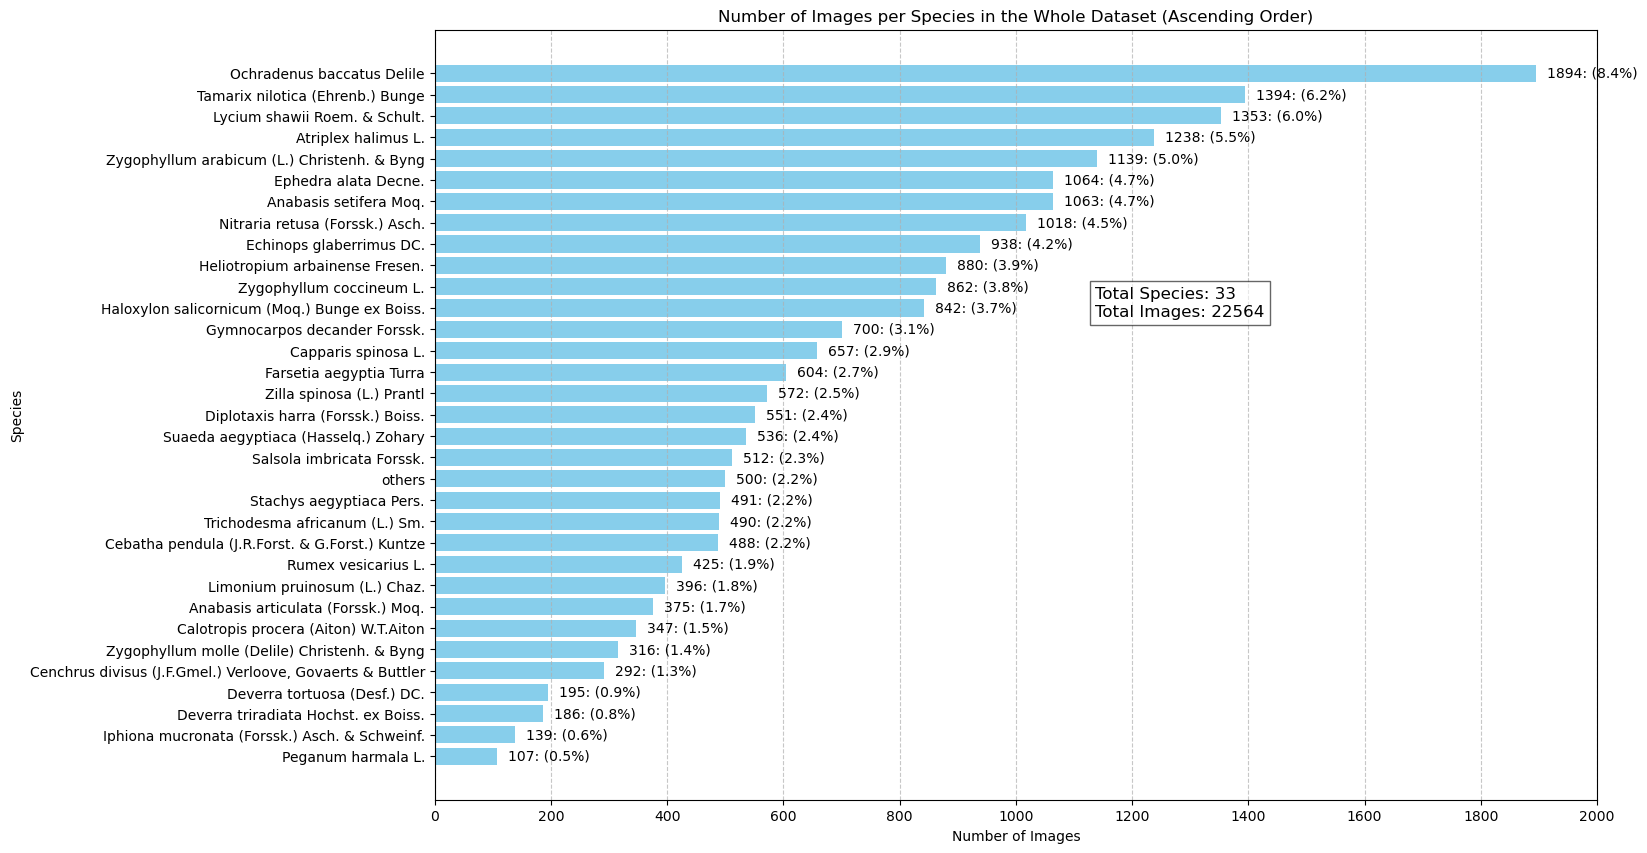

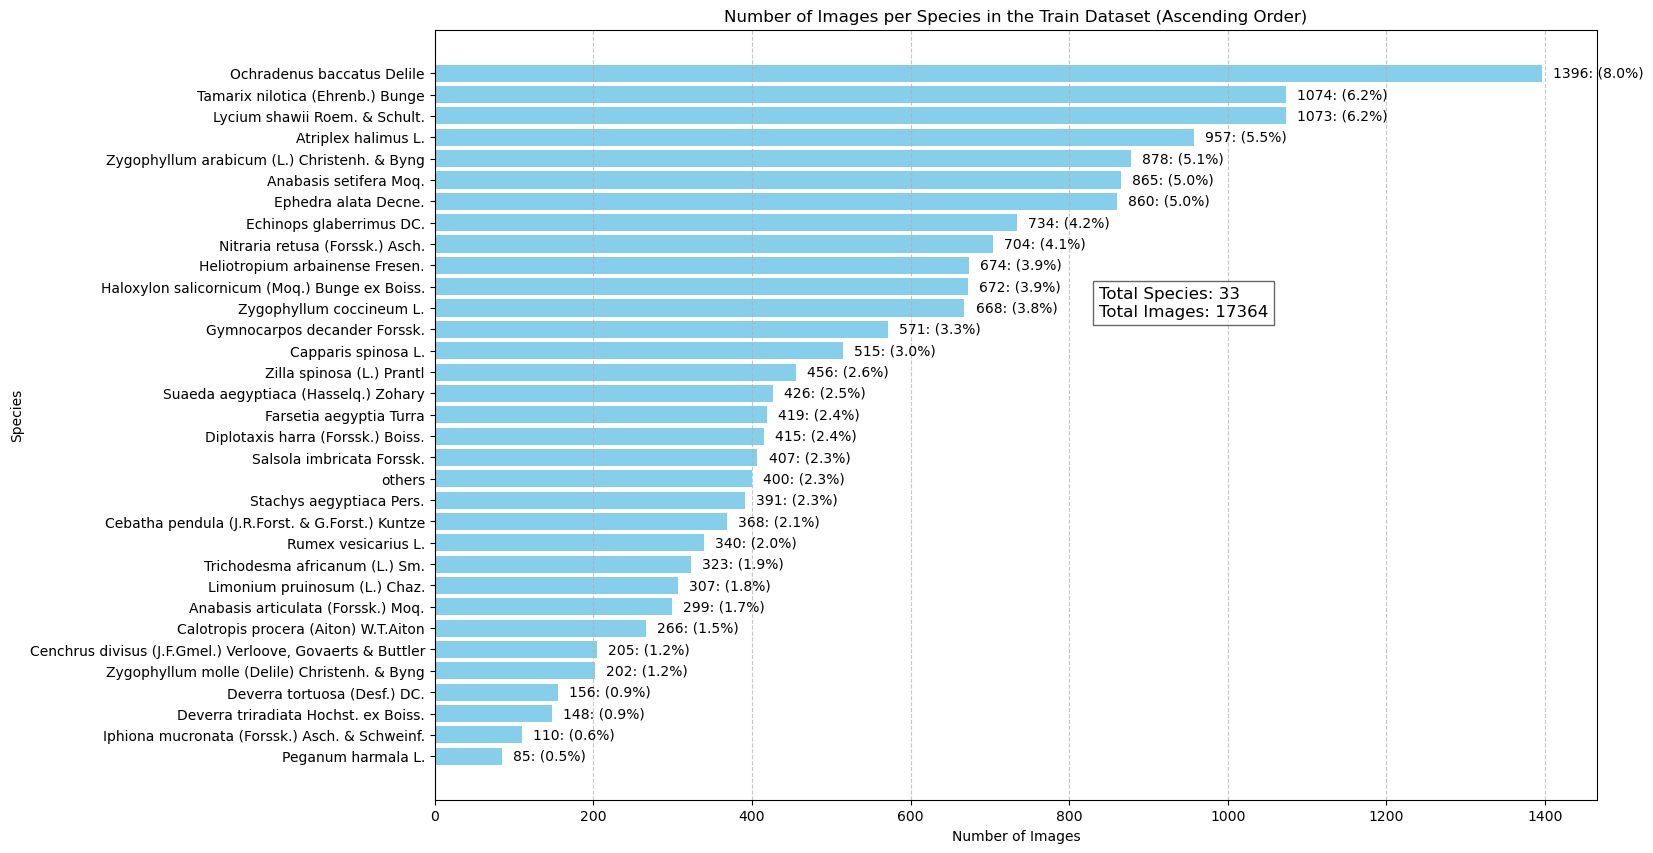

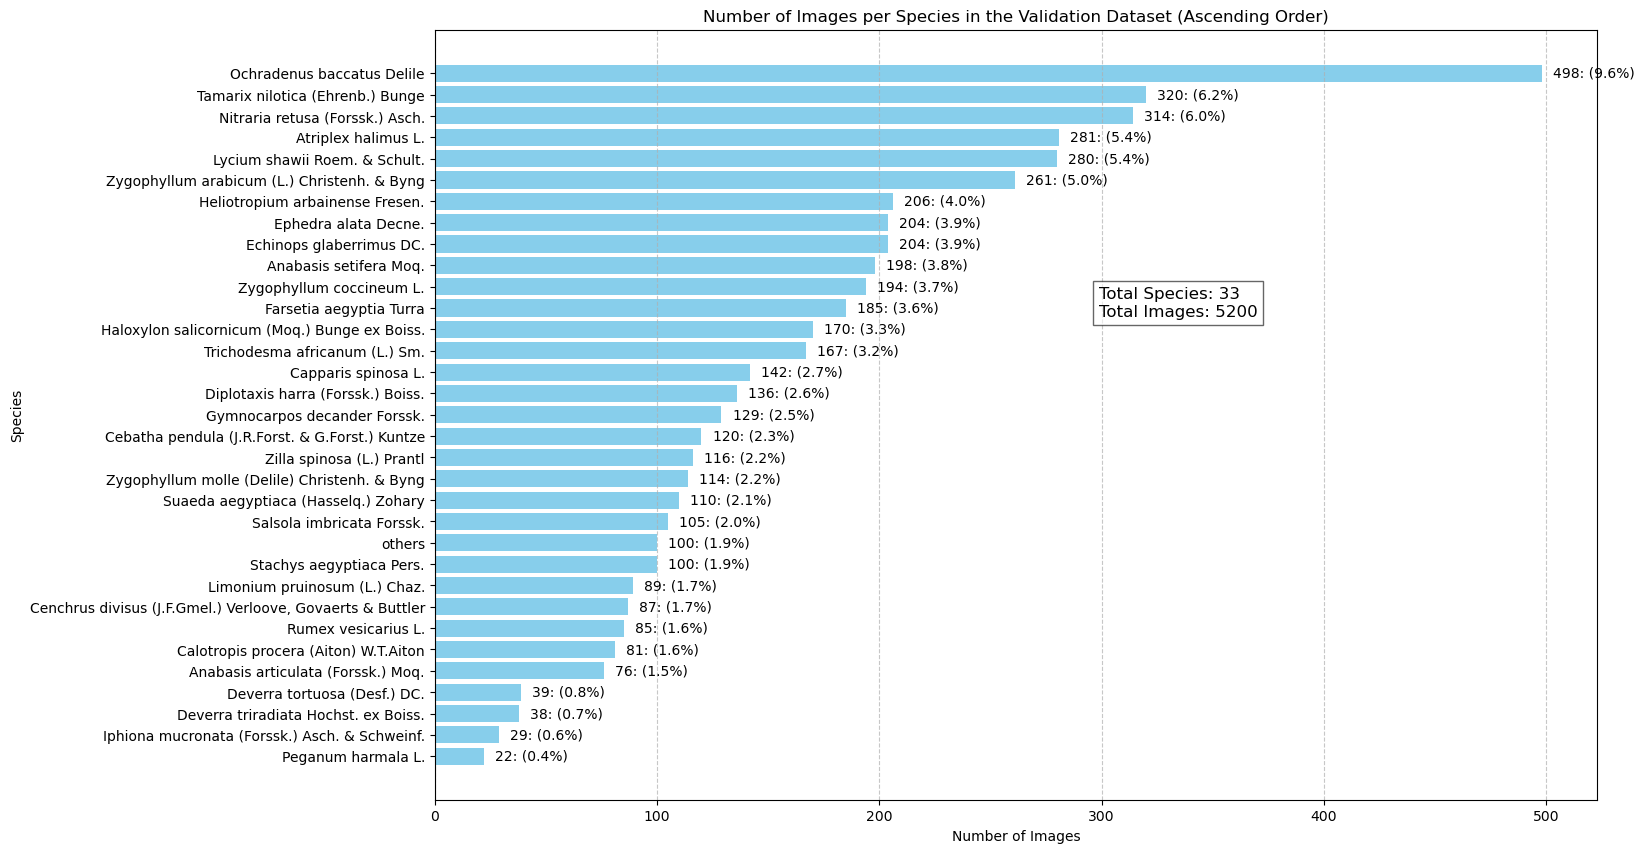

In [28]:
plot_species_image_counts(full_dataset_wrapped, dataset_type="Whole", x_interval=200, save=True)
plot_species_image_counts(train_dataset, dataset_type="Train", x_interval=200, save=True)
plot_species_image_counts(val_dataset, dataset_type="Validation", x_interval=100, save=True)